### GW tutorial 3: Generation of data and matched filtering

Author: Melissa Lopez

Email: m.lopez@uu.nl

In [57]:
%matplotlib inline
from pycbc.catalog import Merger
import pycbc.psd, pycbc.noise
import pylab
import matplotlib.pyplot as plt
import numpy as np
from pycbc.waveform import get_td_waveform
from pycbc.detector import Detector
import random

Previously, we have plotted the PSD of different detectors. Some PSDs are from previous runs (O3), while some others are the design sensitivity of future detectors.

The PSD characterizes the noise of the detector, so we can generate detector noise accordingly.

**Exercise 1:** Load the `aligo_O4high.txt` PSD to [generate](https://pycbc.org/pycbc/latest/html/pycbc.noise.html#pycbc.noise.gaussian.noise_from_psd) some Gaussian data.

_Hint:_ Minimum frequency is 10 Hz, sampling rate 4096 Hz and we want 20s of duration

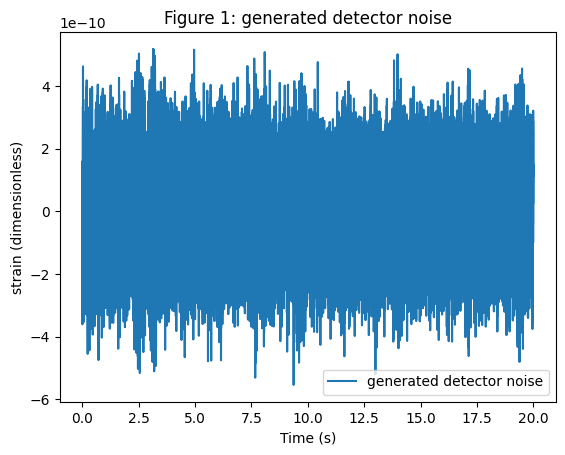

In [68]:
psd_file = open("/content/aligo_O4high.txt")

duration = 20
sample_rate = 4096
min_hz = 10

delta_f = 1/duration
delta_t = 1/sample_rate

length = sample_rate * duration

psd = pycbc.psd.read.from_txt(psd_file, length, delta_f, 12, False)

gen_data = pycbc.noise.gaussian.noise_from_psd(length=length, delta_t=delta_t, psd=psd, seed=None)

plt.plot(gen_data.sample_times, gen_data, label="generated detector noise")
plt.xlabel("Time (s)")
plt.ylabel("strain (dimensionless)")
plt.title("Figure 1: generated detector noise")
plt.legend()


As you can see. the generated noise is "coloured" according to the detector noise. Now, we would like to add a simulated gravitational wave signal in our detector noise.

**Exercise 2:** Using [this function](https://pycbc.org/pycbc/latest/html/pycbc.waveform.html#pycbc.waveform.waveform.get_td_waveform) to generate waveforms in time domain, provide the plus and cross polarization of a binary black hole merger of $m_{1} = m_{2} = 50$ at 2000 Mpc. Use the waveform approximant "IMRPhenomD". How does the waveform amplitude compare to the detector noise?

The waveform comes from the source, but it needs to be projected in the detector. [Project](https://pycbc.org/pycbc/latest/html/pycbc.detector.html#pycbc.detector.ground.Detector.project_wave) the waveform on LIGO Livingston (L1) at random sky-location and polarization. You can specify your detector with [this](https://pycbc.org/pycbc/latest/html/pycbc.detector.html#pycbc.detector.ground.Detector) function. How does the waveform change because of this projection?

_Hint:_ Right ascension range is $[0, 2\pi]$, declination is $[-2\pi, 2\pi]$ and polarization is $[0, 2\pi]$.

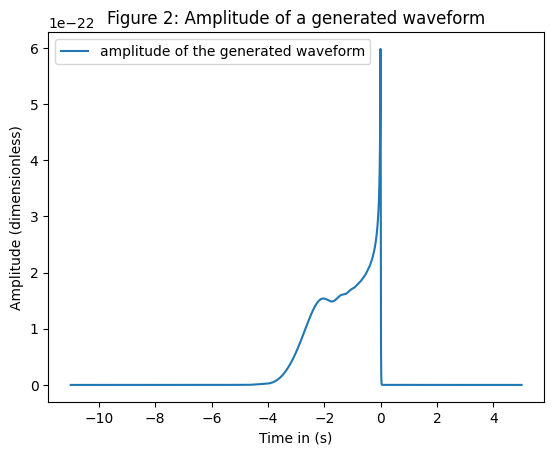

In [69]:
m1 = 50
m2 = 50
d = 2000

gen_waveform = pycbc.waveform.waveform.get_td_waveform(mass1=m1, mass2=m2, distance=d, f_lower=10, delta_t=delta_t, approximant='IMRPhenomD')
hplus, hcross = gen_waveform      #Time series

amplitude = np.sqrt(hplus**2 + hcross**2)       #TimeSeries

plt.plot(hplus.sample_times, amplitude, label="amplitude of the generated waveform")
plt.xlabel("Time in (s)") #?
plt.ylabel("Amplitude (dimensionless)")
plt.title("Figure 2: Amplitude of a generated waveform")
plt.legend()

What i am doing above:
1. write down the given values for mass 1 and 2 and the distance
2. generate the waveform using the given function and separate the two outputs into two different time series
3. calculate the amplitude from the time series
4. plot the amplitude

Question from the Exercise: How does the waveform amplitude compare to the detector noise?

Answer: the amplitude of this generated waveform goes up to only 6*e-22, while the detector noise generated before has amplitudes in a range of e-20, which is much higher

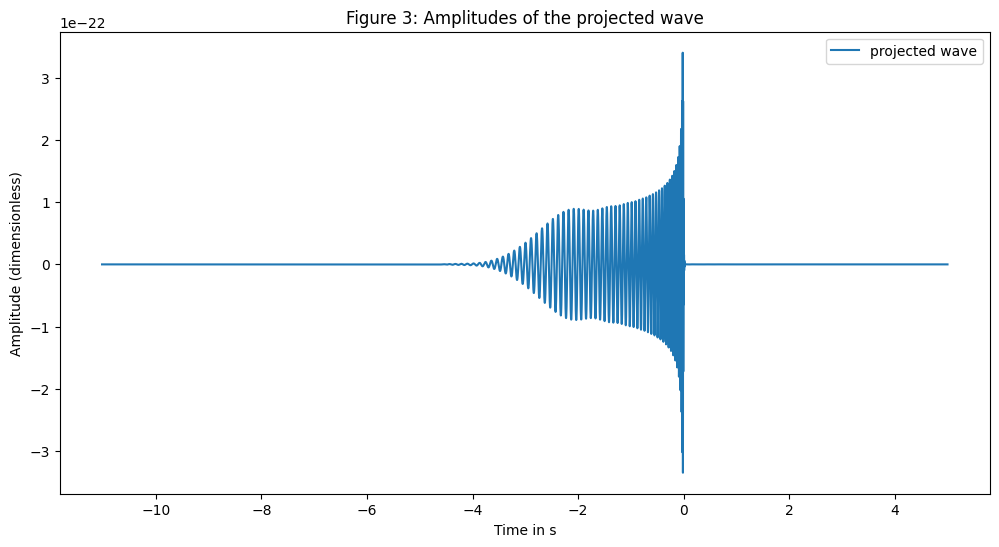

In [70]:
ra = np.random.uniform(0, 2*np.pi)
dec = np.random.uniform(-2*np.pi, 2*np.pi)
pol = np.random.uniform(0, 2*np.pi)

detector = pycbc.detector.ground.Detector(detector_name="L1", reference_time=1126259462.0)    # I kept the reference time as the default, because I did not know what would be the correct thing to do
proj_w = detector.project_wave(hplus, hcross, ra=ra, dec=dec, polarization=pol)

plt.figure(figsize=[12,6])
plt.plot(proj_w.sample_times, proj_w, label="projected wave")
plt.xlabel("Time in s")
plt.ylabel("Amplitude (dimensionless)")
plt.title("Figure 3: Amplitudes of the projected wave")
plt.legend()

What i did in the piece of code before:
1. get random numbers for right ascension (ra), declination (dec) and polarization (pol) in the given ranges
2. define the detector
3. project the wave
4. plot the wave

Question from the exercise: How does the waveform change because of this projection?

Answer: the amplitudes are formed into a wave-pattern around zero, so their value on the y-axis is now ± the half of what it was before.


**Exercise 2:** From before our detector noise is 20s long. Add the GW into noise after 5s. We also need to get the first 4s to estimate the PSD in the next excercise. Make an overlaid plot with the total data, the portion of data where the GW is added and the data needed to estimate the PSD.

_Bonus:_ Can you also plot the GW signal?


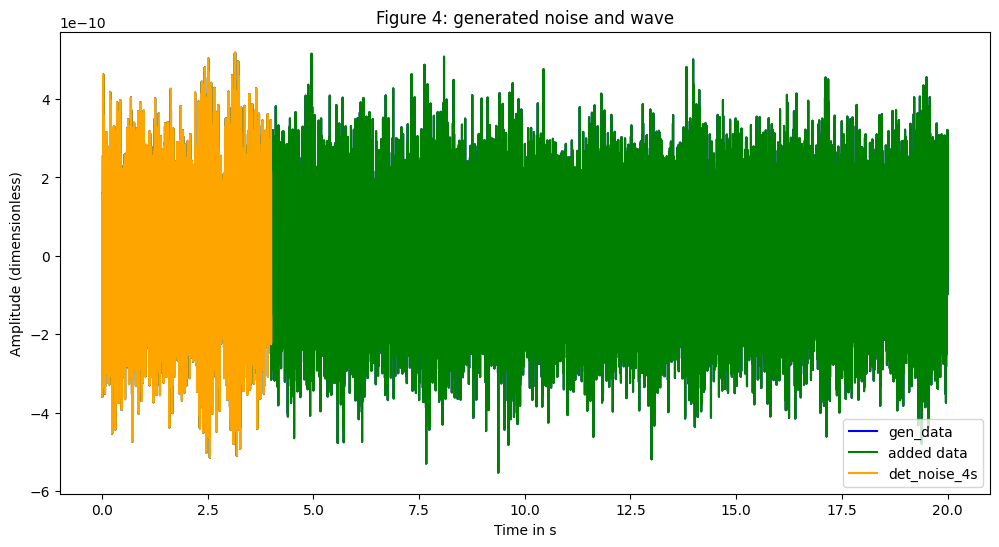

In [71]:
det_noise_4s = gen_data.crop(0, 16)       #first 4s of detector noise, TimeSeries

delay = 5.0
shift_samples = int(delay / gen_data.delta_t)

proj_w_shifted = proj_w.copy()
proj_w_shifted.prepend_zeros(shift_samples)

proj_w_shifted.start_time = gen_data.start_time

proj_w_shifted = proj_w_shifted[:len(gen_data)]

gen_data_2 = gen_data.copy()
gen_data_2 += proj_w_shifted

plt.figure(figsize=(12, 6))
plt.plot(gen_data.sample_times, gen_data, label="gen_data", color="blue")   # original generated data
plt.plot(gen_data_2.sample_times, gen_data_2, label="added data", color="green")    # generated data with added generated waveform
plt.plot(det_noise_4s.sample_times, det_noise_4s, label="det_noise_4s", color="orange")   # first four seconds of generadted data without wave
plt.xlabel("Time in s")
plt.ylabel("Amplitude (dimensionless)")
plt.title("Figure 4: generated noise and wave")
plt.legend()

Explanation of the code above:
1. det_noise_4s are the first four seconds of the generated noise that we are going to use later
2. delay is the time after which we should add the projected wave (proj_w) into the generated noise (gen_data), and shift_samples is the time that the projected wave has to be shifted to do so.
3. then the projected shifted wave (proj_w_shifted) is defined to be the same as the projected wave, but shifted to the right by five seconds. To do so, i am adding zeros in front.
4. Next, the end of the shifted projected wave is cut to make it the same length as the generated noise
5. then the shifted wave is added to the generated noise (the result is gen_data_2)
6. Lastly, the plot is made showing the original generated noise in blue (it is "behind" the other graphs in the plot), the first four seconds of the original data in orange, and the generated noise with the added projected wave in green

/tmp/ipython-input-3101842171.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


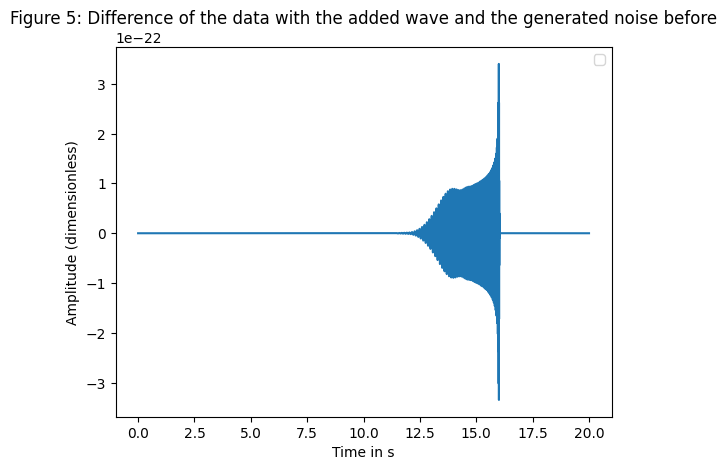

In [72]:
diff = gen_data_2 - gen_data
plt.plot(diff.sample_times, diff)
plt.xlabel("Time in s")
plt.ylabel("Amplitude (dimensionless)")
plt.title("Figure 5: Difference of the data with the added wave and the generated noise before")
plt.legend()

This part of the code was not requested, I just wanted to make sure that gen_data_2 actually has the wave added to it, by subtracting gen_data from gen_data_2 and then plotting the difference. As you can see, the wave is there, it just cannot be seen in the graph above, because its order is much smaller than the generated noise.

**Exercise 3:** In a proper search we do not really have the PSD handy. We want to estimate the PSD with Welch's method (see [here](https://ccrma.stanford.edu/~jos/sasp/Welch_s_Method.html) for details), but we want to use the 4s of the beginning where the GW is not present using [this function](https://pycbc.org/pycbc/latest/html/pycbc.psd.html#pycbc.psd.estimate.welch). Plot the estimated PSD. Note that before we used a dummy whitening, and this one is a bit better.

What is the $\Delta_f$ of the estimated PSD? What is $\Delta_f$ of the data we want to whiten to see the GW signal?

_Hint:_ `seg_stride (int)` is usually half of `seg_len`.


16384
16384
16384
16384 8192
d_f_est_psd: 0.25
delta_f: 0.05


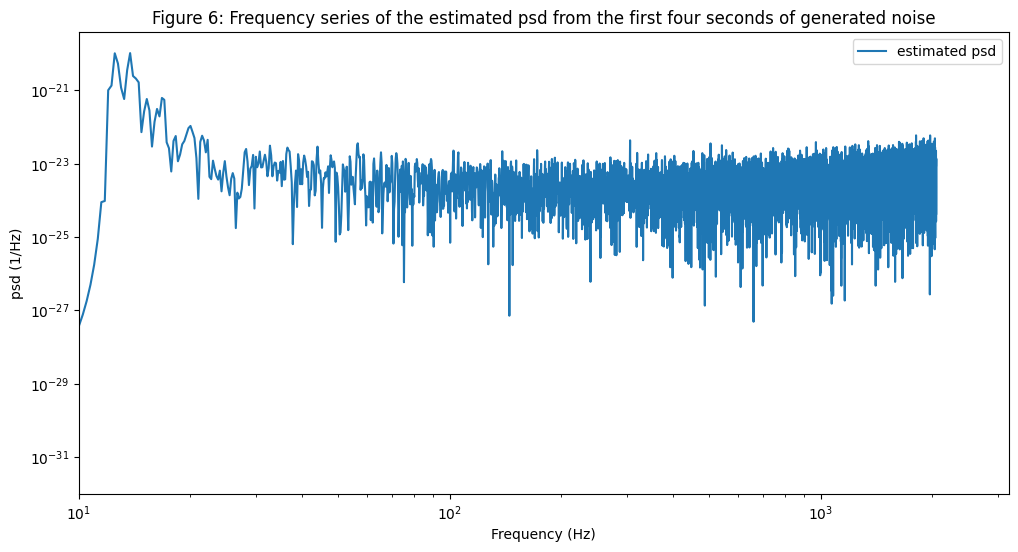

In [73]:

seg_len = len(det_noise_4s)
seg_stride = int(seg_len/2)
est_psd = pycbc.psd.estimate.welch(det_noise_4s, seg_len=seg_len, seg_stride=seg_stride, window='hann', avg_method='median', num_segments=None, require_exact_data_fit=False)

plt.figure(figsize=(12,6))
plt.loglog(est_psd.get_sample_frequencies(), est_psd, label="estimated psd")
plt.xlim(10, None)
plt.xlabel("Frequency (Hz)")
plt.ylabel("psd (1/Hz)")
plt.title("Figure 6: Frequency series of the estimated psd from the first four seconds of generated noise")
plt.legend()

d_f_est_psd = est_psd.delta_f
print("d_f_est_psd:", d_f_est_psd)
print("delta_f:", delta_f)

est_psd_fs = est_psd.to_frequencyseries()
est_psd_ts = est_psd_fs.to_timeseries


An explanation of the code above:
1. the psd is estimated from the first four seconds of the noise (det_noise_4s) using the welch's-method. To do so, seg_len and seg_stride are defined before
2. The estimated psd (est_psd) is plotted in a graph, using logarithmic axes and limiting the x-axis to frequencies above 10hz to be able to see the result better
3. Finally, delta_f of the generated noise (delta_f) and of the estimated psd (d_f_est_psd) are printed to compare them. delta_f=0.05 and d_f_est_psd=0.25, so it is five times as big as delta_f


Now that we have the PSD we need to interpolate it to match our data and then limit the filter length of 1 / PSD. After this, we can directly use this PSD to filter the data. Since the data has been highpassed above 12 Hz, and will have low values below this we need to informat the function to not include frequencies below this frequency.

**Exercise 4:** Use the functions [interpolate](https://pycbc.org/pycbc/latest/html/pycbc.psd.html#pycbc.psd.estimate.interpolate) and [inverse_spectrum_truncation](https://pycbc.org/pycbc/latest/html/pycbc.psd.html#pycbc.psd.estimate.inverse_spectrum_truncation) to achieve a proper formatting of the PSD.

_Hint:_ `max_filter_len (int)` is $4 \times$ sampling_rate. Note that the original PSD has a minimum frequency of 12Hz.

4096.0


'plt.plot(interp.get_sample_frequencies(), interp)'

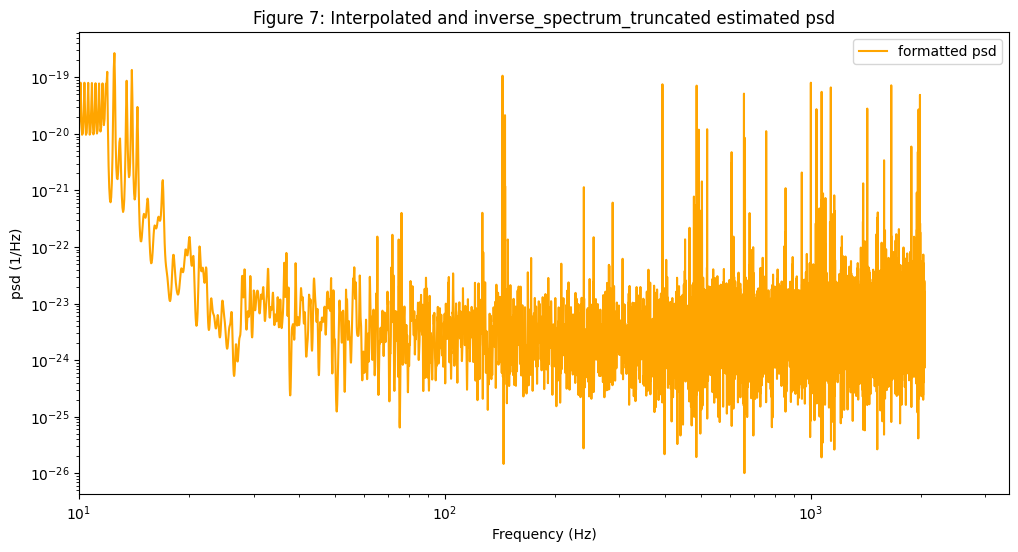

In [74]:
interp = pycbc.psd.estimate.interpolate(est_psd, delta_f, length=None)
sample_rate = 1 / est_psd.delta_t
print(sample_rate)
max_filter_len = int(4* sample_rate)
inv_s_trunc = pycbc.psd.estimate.inverse_spectrum_truncation(psd, max_filter_len, low_frequency_cutoff=12, trunc_method=None)
inv_s_trunc_interp = pycbc.psd.estimate.inverse_spectrum_truncation(interp, max_filter_len, low_frequency_cutoff=12, trunc_method=None)
# Which of the above two do i have to plot?


plt.figure(figsize=(12, 6))
"""plt.plot(inv_s_trunc.get_sample_frequencies(), inv_s_trunc)"""
plt.loglog(inv_s_trunc_interp.get_sample_frequencies(), inv_s_trunc_interp, color="orange", label="formatted psd")
plt.xlim(10, None)
plt.xlabel("Frequency (Hz)")
plt.ylabel("psd (1/Hz)")
plt.title("Figure 7: Interpolated and inverse_spectrum_truncated estimated psd")
plt.legend()
"""plt.plot(interp.get_sample_frequencies(), interp)"""

Explanation of the code above:
1. interpolating the estimated psd using the given function (the result is called interp)
2. setting sample_rate and max_filter_len
3. inverse_spectrum_truncating the interpolated estimated psd (inv_s_trunc_interp)
4. plotting the result of 3., again using a log-scale and only showing the part of the x-axis that is higher than 10Hz, because the minimum frequency of the psd is 12 Hz


Now that the PSD is ready, we can whiten the data. Before we used a PyCBC function, but mathematically this is defined as

\begin{equation}
\tilde{d_w}(f) = \tilde{d}(f)/S_{n}^{-1/2}(f)
\end{equation}
where $\tilde{d}$ and $\tilde{d_w}(f)$ are the Fourier transform of the coloured data and whitened data, respectively.

**Exercise 5:** Whiten the data using the interpolated PSD. Crop 5s at the beginning and the end to avoid border effects (_aliasing_) and bandpass it as in the previous exercise. Can you see the GW signal?

Text(0.5, 1.0, 'Figure 8: Whitened psd-data')

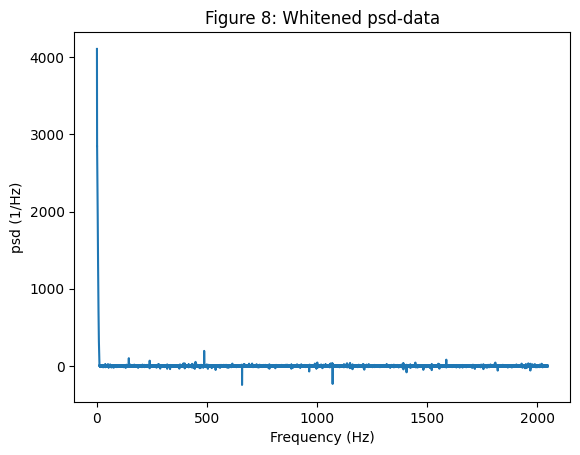

In [75]:
gen_data_2_fs = gen_data_2.to_frequencyseries()

w_data_2 = gen_data_2_fs/interp**0.5

plt.plot(w_data_2.get_sample_frequencies(), w_data_2)
plt.xlabel("Frequency (Hz)")
plt.ylabel("psd (1/Hz)")
plt.title("Figure 8: Whitened psd-data")

Above I whitened and then plotted the data using the formula we were given.

Text(0.5, 1.0, 'Figure 9: whitened, cropped and bandpassed data')

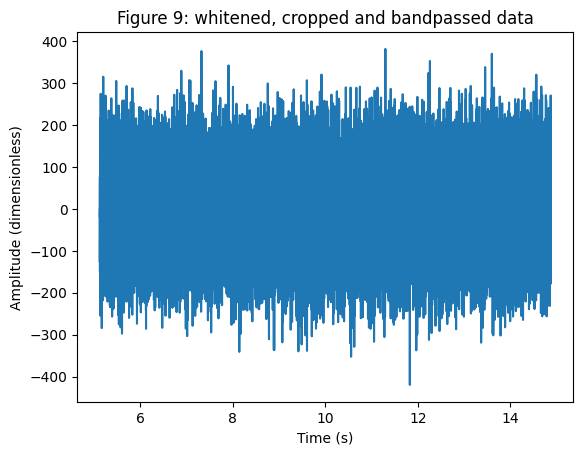

In [76]:
w_data_2_ts = w_data_2.to_timeseries()

w_data_2_ts_c = w_data_2_ts.crop(5, 5)

w_data_2_ts_c_bp = w_data_2_ts_c.highpass_fir(12, 512)

plt.plot(w_data_2_ts_c_bp.sample_times, w_data_2_ts_c_bp)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (dimensionless)")
plt.title("Figure 9: whitened, cropped and bandpassed data")

Here, I am first converting the whitened data (w_data_2) into a time series, then i am cutting (five seconds on each side) and bandpassing (no smaller frequencies than 12 Hz) it as instructed, and then plotting a graph again.

Note: I was expecting some kind of clear signal emerging, however this looks rather similar to the first plot of generated data with no clear peaks or trends, so I assume, I made a mistake somewhere, I just do not know where.

So far, we buried a GW signal  $h(t)$ in stationary and Gaussian noise $n(t)$ with zero mean, such that $s(t) = h(t) + n(t)$. Given the optimal filter  $K(t)$,

\begin{equation}
\label{eq:filteredsignal}
\hat{s} = \int_{-\infty}^{\infty}  K(t)s(t) dt = \int_{-\infty}^{\infty} \tilde{K}(f)^{*}\tilde{s}(f) df, \quad \text{ where }  \tilde{s}(f) = \int_{-\infty}^{\infty} s(t)e^{-2 \pi i ft}dt
\end{equation}
where $\hat{s}$ is the filtered value of $s(t)$, $^*$ represents the complex conjugate, and $\tilde{\cdot }\ $ the Fourier transform.

The detection statistic that is maximised by the optimal filter $K(t)$  will be the SNR, defined as $\rho = S/N$. $S$ is the expected value of $\hat{s}$ when $h(t) \neq 0$, while $N$ is the squared root of the noise variance when $h(t) =0$. It can be demonstrated that the optimal filter $K(t)$ is the model of the GW signal itself, known as _template_.

The fundamental modelled detection technique is called "matched filtering", since the filter function is chosen to "match" the signal we are looking for. We can write the SNR between an unknown time series $s(t)$ and the template $h_{m}$ as

\begin{equation}
\label{eq:wienerscalar}
\rho =  4 \text{Re} \int_{0}^{\infty} \frac{\tilde{s}^{*}(f)}{S_{n}(f)} \tilde{h_{m}}(f) df.
\end{equation}



**Exercise 6:** Use the [matched_filter](https://pycbc.org/pycbc/latest/html/pycbc.filter.html#pycbc.filter.matchedfilter.matched_filter) function to filter the coloured data with the template. Crop the SNR time series 5s at each side and plot it together with the whitened data. Where is the GW signal? Note that the y-axis of the whitened data is _amplitude_ and the y-axis of the SNR timeseries is _SNR_.

How much is the maximum of the absolute value of the SNR time series? If it is larger than 5 it will generate a "trigger" for further analysis. Will the trigger be generated?

Note that the parameter space of GW signals is vast, so to find these signals, we will need to create a template bank and do this process for thousands of templates. Then, this becomes a high-performance computing problem!

_Hint_: you need to [resize](https://pycbc.org/pycbc/latest/html/pycbc.types.html#pycbc.types.array.Array.resize) the template and use [cyclic_time_shift](https://pycbc.org/pycbc/latest/html/pycbc.types.html#pycbc.types.frequencyseries.FrequencySeries.cyclic_time_shift)

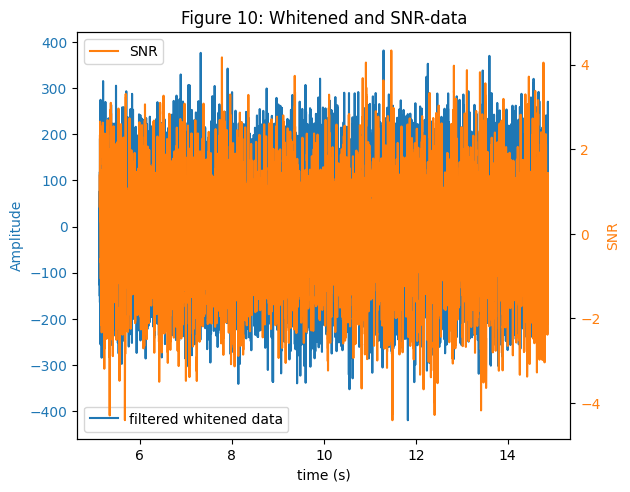

Maximum absolute value of the SNR-data: 5.477894833453313


In [77]:
from pycbc.types import TimeSeries

templ = TimeSeries(
    proj_w_shifted.data[:len(w_data_2_ts_c_bp)],
    delta_t=proj_w_shifted.delta_t,
    epoch=proj_w_shifted.start_time
)

templ2 = templ.cyclic_time_shift(5)

filtered_coloured_data = pycbc.filter.matchedfilter.matched_filter(template=templ2, data=w_data_2_ts_c_bp, psd=None, low_frequency_cutoff=12, high_frequency_cutoff=None, sigmasq=None)

fig, ax1 = plt.subplots()

color = 'tab:blue'
ax1.set_xlabel('time (s)')
ax1.set_ylabel('Amplitude', color=color)
ax1.plot(w_data_2_ts_c_bp.sample_times, w_data_2_ts_c_bp, color=color, label="filtered whitened data")
ax1.tick_params(axis='y', labelcolor=color)
plt.legend()
ax2 = ax1.twinx()

color = 'tab:orange'
ax2.set_ylabel('SNR', color=color)
ax2.plot(filtered_coloured_data.sample_times, filtered_coloured_data, color=color, label="SNR")
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()
plt.title("Figure 10: Whitened and SNR-data")
plt.legend()
plt.show()


print("Maximum absolute value of the SNR-data:", max(abs(filtered_coloured_data)))



My final attempt to solve the last exercise.
I did not find out, how to use the resize()-function, since it does not return a time series anymore, the matched_filter()-function can not use it and I did not find out, how to solve this. Therefore, I used another function that cuts the time series to the desired length while keeping it as a time series.

My next point of confusion was by how much to shift the template, so I ended up doing it by 5s, because the projected wave was added to the noise after 5s, but i have no idea if that is anywhere close to being correct.

Finally, I used the matched_filter()-function with the time series I assumed I had to use, however once again, I am not sure if it is actually correct, and then plotted both the whitened data and the filtered data (SNR data).

In the last run of this file I made, the maximum absolute value of the SNR-data is 5.48, which bigger than 5, so the trigger for further analysis will be generated.

To plot this last graph, I used the code from this website to get a graph with two y-axes: https://matplotlib.org/stable/gallery/subplots_axes_and_figures/two_scales.html (retrieved 10.02.2026)
The resizing of the time series was done using chatgpt because of the lack of time to figure this out myself.


Good job arriving at the end of the tutorial! This was a small peak at GW data analysis that I hope you found interesting.

There is a bonus track exercise if you are bored, but we can also have a chat about some more GW data analysis if you prefer.